In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
def dijkstra_algorithm(graph, source, destination):
    """
    Implements Dijkstra's Algorithm to find the shortest path
    in a graph with non-negative weights.
    """
    # Initialize distances (infinity for all, 0 for the source)
    distances = {vertex: float('infinity') for vertex in graph}
    distances[source] = 0

    # Dictionary to store the path (predecessors)
    predecessors = {vertex: None for vertex in graph}

    # Priority queue to always extract the node with the lowest known distance
    # Format: (accumulated_distance, current_vertex)
    priority_queue = [(0, source)]

    while priority_queue:
        current_distance, current_vertex = heapq.heappop(priority_queue)

        # If we reached the destination, we can stop the exploration early
        if current_vertex == destination:
            break

        # If the extracted distance is greater than the stored one, ignore it
        if current_distance > distances[current_vertex]:
            continue

        # Analyze the neighbors of the current vertex
        for neighbor, weight in graph[current_vertex].items():
            alternative_distance = current_distance + weight

            # If we find a shorter path to the neighbor, update it
            if alternative_distance < distances[neighbor]:
                distances[neighbor] = alternative_distance
                predecessors[neighbor] = current_vertex
                heapq.heappush(
                    priority_queue,
                    (alternative_distance, neighbor)
                )

    # Path reconstruction starting from the predecessors
    final_path = []
    current_node = destination

    while current_node is not None:
        final_path.insert(0, current_node)
        current_node = predecessors[current_node]

    return final_path, distances[destination]


--- DIJKSTRA'S ALGORITHM RESULT ---
Shortest Path Found: 0 -> 2 -> 1 -> 3 -> 4
Total Minimum Cost: 5
-----------------------------------


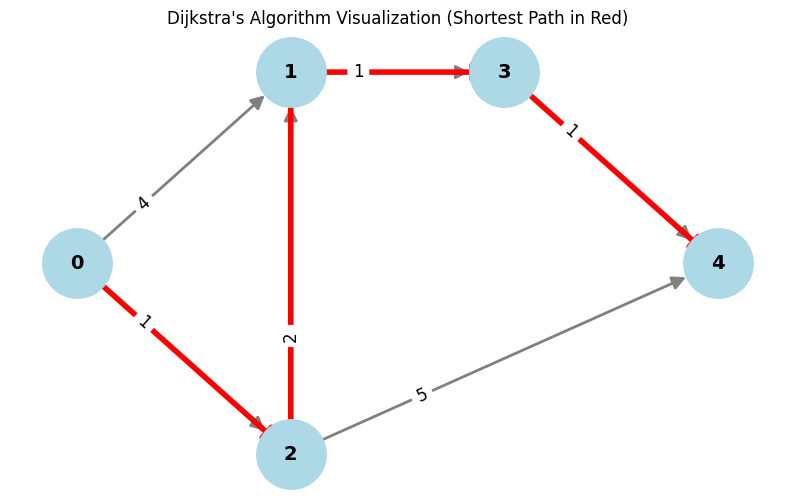

In [5]:
# 1. Directed Graph configuration based on the problem
dijkstra_graph = {
    0: {1: 4, 2: 1},
    1: {3: 1},
    2: {1: 2, 4: 5},
    3: {4: 1},
    4: {}  # Node 4 has no outgoing edges
}

# 2. Execute the algorithm starting from node 0 to node 4
path, total_cost = dijkstra_algorithm(dijkstra_graph, 0, 4)

# 3. Printing the results
print("--- DIJKSTRA'S ALGORITHM RESULT ---")
print(f"Shortest Path Found: {' -> '.join(map(str, path))}")
print(f"Total Minimum Cost: {total_cost}")
print("-" * 35)

# 4. Graphical Visualization of the Directed Graph
G = nx.DiGraph()

# Add edges to the networkx object
for source, connections in dijkstra_graph.items():
    for destination, weight in connections.items():
        G.add_edge(source, destination, weight=weight)

# Define a layout to facilitate visualization of progression (left to right)
pos = {
    0: (0, 1),
    1: (1, 1.5),
    2: (1, 0.5),
    3: (2, 1.5),
    4: (3, 1)
}

plt.figure(figsize=(10, 6))
plt.title("Dijkstra's Algorithm Visualization (Shortest Path in Red)")

# Draw all edges and nodes in gray and blue
nx.draw(
    G, pos,
    with_labels=True,
    node_color='lightblue',
    node_size=2500,
    font_size=14,
    font_weight='bold',
    edge_color='gray',
    arrows=True,
    arrowsize=20,
    width=2
)

# Highlight the shortest path found
path_edges = [
    (path[i], path[i+1]) for i in range(len(path) - 1)
]

nx.draw_networkx_edges(
    G, pos,
    edgelist=path_edges,
    edge_color='red',
    arrows=True,
    arrowsize=25,
    width=4
)

# Add weight labels to the edges
edge_weight_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_weight_labels,
    font_size=12,
    label_pos=0.3
)

plt.show()